## **Combining DataFrame exported to vertebral_column_data.csv**

In [1]:
pip install ucimlrepo

In [25]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam

In [3]:
# fetch dataset
vertebral_column = fetch_ucirepo(id=212)

# # data (as pandas dataframes)
X = vertebral_column.data.features
y = vertebral_column.data.targets

combined_df = pd.concat([X, y], axis=1)
combined_df.to_csv('vertebral_column_data.csv', index=False)

print(X.head())
print(y['class'].unique())
# # metadata
#print(vertebral_column.metadata)

 # variable information
#print(vertebral_column.variables)



   pelvic_incidence  pelvic_tilt  lumbar_lordosis_angle  sacral_slope  \
0         63.027817    22.552586              39.609117     40.475232   
1         39.056951    10.060991              25.015378     28.995960   
2         68.832021    22.218482              50.092194     46.613539   
3         69.297008    24.652878              44.311238     44.644130   
4         49.712859     9.652075              28.317406     40.060784   

   pelvic_radius  degree_spondylolisthesis  
0      98.672917                 -0.254400  
1     114.405425                  4.564259  
2     105.985135                 -3.530317  
3     101.868495                 11.211523  
4     108.168725                  7.918501  
['Hernia' 'Spondylolisthesis' 'Normal']


In [4]:
X.to_csv('features.csv', index=False)
y.to_csv('targets.csv', index=False)
print("DataFrames exported to features.csv and targets.csv")

DataFrames exported to features.csv and targets.csv


In [6]:
combined_df = pd.concat([X, y], axis=1)
combined_df.to_csv('vertebral_column_data.csv', index=False)
print("Combined DataFrame exported to vertebral_column_data.csv")

Combined DataFrame exported to vertebral_column_data.csv


## **Describe preparations of the training and testing data and normalization of the data**

In [21]:
print("=====1. Load & Inspect Data=====")

## 1. Load & Inspect Data
df = pd.read_csv('vertebral_column_data.csv')

print("Dataset Shape:", df.shape)
print("\nClass Distribution:\n", df['class'].value_counts())
print("\nMissing Values:\n", df.isnull().sum())
print("\nFeature Statistics:\n", df.describe())

print("=====2. Label Encoding=====")
## 2. Label Encoding

# 0 = Normal, 1 = Abnormal (Hernia or Spondylolisthesis)
df['target'] = df['class'].apply(lambda x: 0 if x == 'Normal' else 1)

print(df[['class', 'target']].drop_duplicates())

print("=====3. Separate Features & Target=====")
## 3. Separate Features & Target
X = df.drop(columns=['class', 'target'])
y = df['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)


print("=====4. Train/Test Split (Stratified)=====")

## 4. Train/Test Split (Stratified/Fair proportion)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # preserves class proportions
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print("\nTraining class distribution:\n", y_train.value_counts())
print("\nTesting class distribution:\n",  y_test.value_counts())



print("=====5. Normalization (StandardScaler)=====")
## 5. Normalization (StandardScaler)

scaler = StandardScaler()

# IMPORTANT: fit on training data ONLY to avoid data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Verify normalization
print("Training set - Mean (should be ~0):\n", X_train_scaled.mean(axis=0).round(4))
print("Training set - Std  (should be ~1):\n", X_train_scaled.std(axis=0).round(4))

print("=====6. Before vs After Comparison=====")
## 6. Before vs After Comparison
print("=== Before Normalization ===")
print(X_train.describe().loc[['min','max','mean','std']].round(2))

print("\n=== After Normalization ===")
scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print(scaled_df.describe().loc[['min','max','mean','std']].round(2))

=====1. Load & Inspect Data=====
Dataset Shape: (310, 7)

Class Distribution:
 class
Spondylolisthesis    150
Normal               100
Hernia                60
Name: count, dtype: int64

Missing Values:
 pelvic_incidence            0
pelvic_tilt                 0
lumbar_lordosis_angle       0
sacral_slope                0
pelvic_radius               0
degree_spondylolisthesis    0
class                       0
dtype: int64

Feature Statistics:
        pelvic_incidence  pelvic_tilt  lumbar_lordosis_angle  sacral_slope  \
count        310.000000   310.000000             310.000000    310.000000   
mean          60.496653    17.542822              51.930930     42.953831   
std           17.236520    10.008330              18.554064     13.423102   
min           26.147921    -6.554948              14.000000     13.366931   
25%           46.430294    10.667069              37.000000     33.347122   
50%           58.691038    16.357689              49.562398     42.404912   
75%         

**Explanation**

The dataset contains 310 samples with 6 biomechanical features and no missing values.
The target class was label-encoded: Normal=0, and any other abonormalities as 1 so Hernia and Spondylolisthesis would be 1.

The data was split into 80% training (248 samples) and 20% testing (62 samples)
using stratified splitting to preserve class proportions across both sets,
which is important since the dataset is imbalanced.

StandardScaler was applied to normalize features to mean=0 and std=1.
The scaler was fitted on the training set only and then applied to the test set
to prevent data leakage. Normalization is necessary because features such as
degree_spondylolisthesis range from -11 to 418, while others like pelvic_tilt
range from -6 to 49 — large scale differences that can negatively affect
distance-based and gradient-based classifiers.

### **B. Describe the architecture of the proposed network.**

**The Architecture**

Input Layer        →  6 neurons  (one per feature)

Hidden Layer 1     →  64 neurons  + ReLU activation

Hidden Layer 2     →  32 neurons  + ReLU activation

Output Layer       →  3 neurons   + Sigmoid activation (output->Binary)

In [24]:
print("=====1. Build the model=====")

## 1. Build The Model

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(6,)),  # Hidden Layer 1
    Dense(32, activation='relu'),                     # Hidden Layer 2
    Dense(1,  activation='softmax')                   # Output Layer
])

model.summary()

print("=====2. Compile the model=====")

## 2. Compile The Model
model.compile(
    optimizer='adam',  # best default choice for small datasets like yours (310 samples)
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("====3. Train the model=====")

## 3. Train the model

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2
)

=====1. Build the model=====


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,561 (10.00 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 0 (0.00 B)

=====2. Compile the model=====
====3. Train the model=====
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.6919 - loss: 0.6409 - val_accuracy: 0.6200 - val_loss: 0.6249
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6919 - loss: 0.5716 - val_accuracy: 0.6200 - val_loss: 0.5782
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6919 - loss: 0.5216 - val_accuracy: 0.6200 - val_loss: 0.5440
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6919 - loss: 0.4817 - val_accuracy: 0.6200 - val_loss: 0.5077
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6919 - loss: 0.4459 - val_accuracy: 0.6200 - val_loss: 0.4766
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6919 - loss: 0.4144 - val_accuracy: 0.6200 - val_loss: 0.4475
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6919 - loss: 0.3888 - val_accuracy: 0.6200 - val_loss: 0.4244
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6919 - loss: 0.3675 - val_accuracy: 0.6200 - val_loss: 0

## **Explanation**

- Model type: Multilayer Perceptron (MLP) for binary classification
- Input Layer: 6 neurons — one for each biomechanical feature
- Hidden Layer 1: 64 neurons with ReLU activation
- Hidden Layer 2: 32 neurons with ReLU activation
- Output Layer: 1 neuron with Sigmoid activation:
outputs a probability between 0 and 1
0 = Normal
1 = Abnormal (Hernia or Spondylolisthesis)


- Optimizer: Adam — fast and works well on small datasets
- Loss Function: Binary Cross-Entropy — used for 2-class classification
- Metric: Accuracy — to monitor performance during training

## **C. Vary learning rate (i.e. 0.01, 0.1, and 0.8) and plot the learning process.**

In [26]:
## Train with 3 Different Learning Rates

learning_rates = [0.01, 0.1, 0.8]
histories = {}

for lr in learning_rates:
    model = Sequential([
        Dense(64, activation='relu', input_shape=(6,)),
        Dense(32, activation='relu'),
        Dense(1,  activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    print(f"\nTraining with learning rate = {lr}")
    history = model.fit(
        X_train_scaled, y_train,
        epochs=100,
        batch_size=16,
        validation_split=0.2,
        verbose=0              # silent training
    )

    histories[lr] = history


Training with learning rate = 0.01

Training with learning rate = 0.1

Training with learning rate = 0.8


##### **Plot the Results**

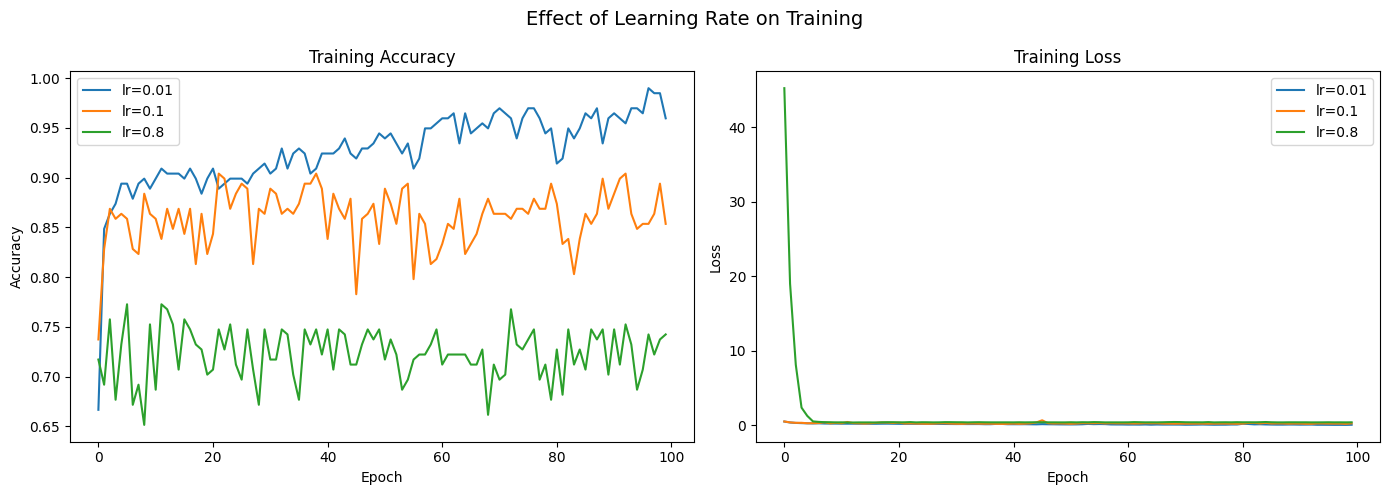

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lr in learning_rates:
    axes[0].plot(histories[lr].history['accuracy'],     label=f'lr={lr}')
    axes[1].plot(histories[lr].history['loss'],         label=f'lr={lr}')

axes[0].set_title('Training Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].set_title('Training Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Effect of Learning Rate on Training', fontsize=14)
plt.tight_layout()
plt.show()

#### **Explanation:**

- **lr=0.01** — model learns slowly but steadily, may not converge in 100 epochs
- **lr=0.1** — best balance between speed and stability
- **lr=0.8** — too aggressive, loss becomes unstable and accuracy fluctuates wildly

## **D. Use two different momentum and comment on the convergence of the network.**

In [28]:
from tensorflow.keras.optimizers import SGD

momentums = [0.0, 0.9]
momentum_histories = {}

for m in momentums:
    model = Sequential([
        Dense(64, activation='relu', input_shape=(6,)),
        Dense(32, activation='relu'),
        Dense(1,  activation='sigmoid')
    ])

    model.compile(
        optimizer=SGD(learning_rate=0.01, momentum=m),  # ← momentum is inside the optimizer used during model.fit() to update weights
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    print(f"\nTraining with momentum = {m}")
    history = model.fit(
        X_train_scaled, y_train,
        epochs=100,
        batch_size=16,
        validation_split=0.2,
        verbose=0
    )

    momentum_histories[m] = history


Training with momentum = 0.0

Training with momentum = 0.9


##### **Plot the Results**

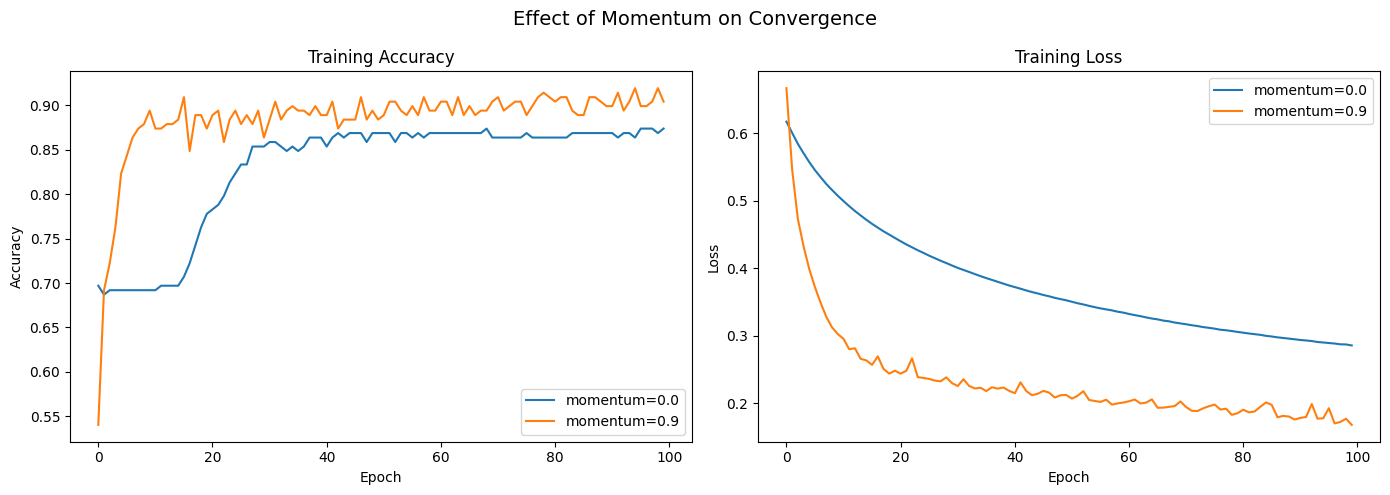

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for m in momentums:
    axes[0].plot(momentum_histories[m].history['accuracy'], label=f'momentum={m}')
    axes[1].plot(momentum_histories[m].history['loss'],     label=f'momentum={m}')

axes[0].set_title('Training Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].set_title('Training Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Effect of Momentum on Convergence', fontsize=14)
plt.tight_layout()
plt.show()

#### **Explanation:**

- **Momentum = 0.0** — network learns slowly, loss decreases gradually, may get stuck in local minima and takes more epochs to converge
- **Momentum = 0.9** — network converges much faster, loss drops quickly and smoothly, reaches better accuracy in fewer epochs because it builds speed in the right direction

## **E. Vary the number of hidden neurons (three different set) and show the effect in testing and training data.**

In [30]:
neuron_sets = [
    (16, 8),    # small
    (64, 32),   # medium
    (128, 64)   # large
]

neuron_histories = {}

for (n1, n2) in neuron_sets:
    model = Sequential([
        Dense(n1, activation='relu', input_shape=(6,)),  # Hidden Layer 1
        Dense(n2, activation='relu'),                     # Hidden Layer 2
        Dense(1,  activation='sigmoid')                   # Output
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.01),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    print(f"\nTraining with neurons = ({n1}, {n2})")
    history = model.fit(
        X_train_scaled, y_train,
        epochs=100,
        batch_size=16,
        validation_split=0.2,
        verbose=0
    )

    neuron_histories[(n1, n2)] = history


Training with neurons = (16, 8)

Training with neurons = (64, 32)

Training with neurons = (128, 64)


### **Training vs Testing Accuracy results**

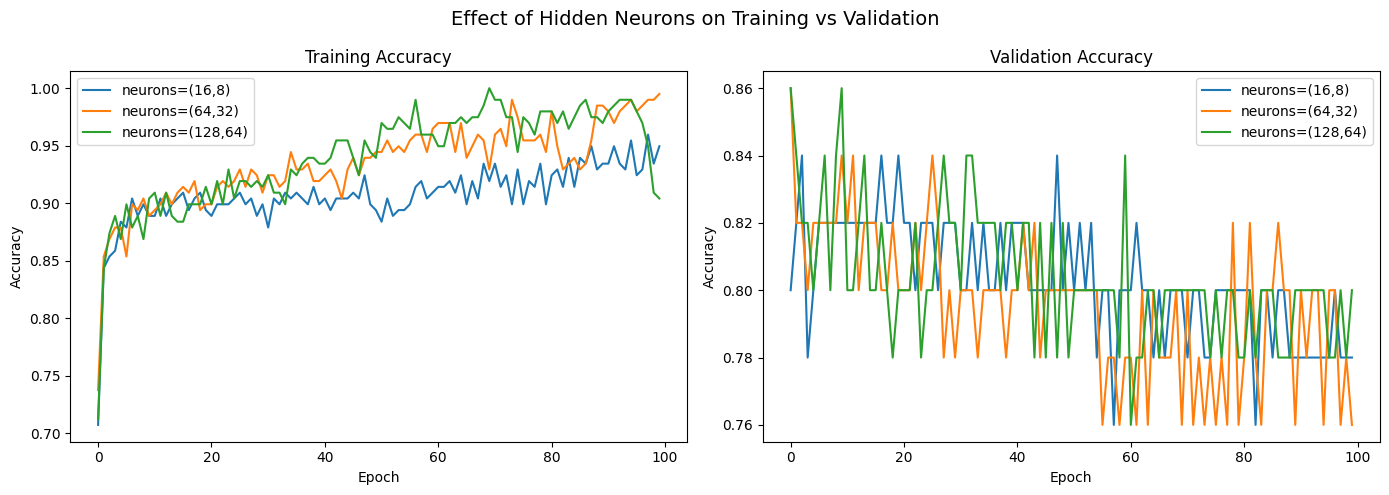

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (n1, n2) in neuron_sets:
    label = f'neurons=({n1},{n2})'
    # training
    axes[0].plot(neuron_histories[(n1,n2)].history['accuracy'],     label=label)
    # validation
    axes[1].plot(neuron_histories[(n1,n2)].history['val_accuracy'], label=label)

axes[0].set_title('Training Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Effect of Hidden Neurons on Training vs Validation', fontsize=14)
plt.tight_layout()
plt.show()

In [32]:
print("=" * 50)
print(f"{'Neurons':<15} {'Train Acc':>10} {'Val Acc':>10}")
print("=" * 50)

for (n1, n2) in neuron_sets:
    train_acc = neuron_histories[(n1,n2)].history['accuracy'][-1]
    val_acc   = neuron_histories[(n1,n2)].history['val_accuracy'][-1]
    print(f"({n1}, {n2}){'':>5} {train_acc:>10.4f} {val_acc:>10.4f}")

Neurons          Train Acc    Val Acc
(16, 8)          0.9495     0.7800
(64, 32)          0.9949     0.7600
(128, 64)          0.9040     0.8000


#### **Explanation:**

- **(16, 8)** — too few neurons, model is too simple to learn the patterns, both training and validation accuracy are low → underfitting
- **(64, 32)** — good balance, training and validation accuracy are close and high → best choice
- **(128, 64)** — too many neurons, training accuracy is very high but validation drops → model memorized training data → overfitting

## **F. Show the classification performance of the network on both testing and training set.**

#### **Train Final Model**

In [33]:
# train the final model first
model = Sequential([
    Dense(64, activation='relu', input_shape=(6,)),  #(64,32 hidden layer neurons decided from the above test done on 3 different set of neurons)
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)


# Get Predictions

# convert probabilities to 0 or 1
y_train_pred = (model.predict(X_train_scaled) > 0.5).astype(int)
y_test_pred  = (model.predict(X_test_scaled)  > 0.5).astype(int)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


#### **Classification Report**

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("=" * 50)
print("TRAINING SET PERFORMANCE")
print("=" * 50)
print(classification_report(y_train, y_train_pred, target_names=['Normal', 'Abnormal']))

print("=" * 50)
print("TESTING SET PERFORMANCE")
print("=" * 50)
print(classification_report(y_test, y_test_pred, target_names=['Normal', 'Abnormal']))



#====Final Accuracy Summary====
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)

print(f"Training Accuracy : {train_acc * 100:.2f}%")
print(f"Testing  Accuracy : {test_acc  * 100:.2f}%")

TRAINING SET PERFORMANCE
              precision    recall  f1-score   support

      Normal       0.94      0.93      0.93        80
    Abnormal       0.96      0.97      0.97       168

    accuracy                           0.96       248
   macro avg       0.95      0.95      0.95       248
weighted avg       0.96      0.96      0.96       248

TESTING SET PERFORMANCE
              precision    recall  f1-score   support

      Normal       0.82      0.70      0.76        20
    Abnormal       0.87      0.93      0.90        42

    accuracy                           0.85        62
   macro avg       0.85      0.81      0.83        62
weighted avg       0.85      0.85      0.85        62

Training Accuracy : 95.56%
Testing  Accuracy : 85.48%


#### **Explanation:**

**Training Set Performance**

- Overall accuracy is 96% which is very high
- For Normal class — precision of 0.94 and recall of 0.93, meaning the model correctly identified 93% of all Normal patients
- For Abnormal class — precision of 0.96 and recall of 0.97, meaning the model caught 97% of all Abnormal patients


**Testing Set Performance**

- Overall accuracy is 85% on unseen data
- For Normal class — recall dropped to 0.70, meaning the model only correctly identified 70% of Normal patients ⚠️
- For Abnormal class — recall remains strong at 0.93, meaning 93% of Abnormal patients were still correctly caught ✅

## **G. Show the MSE for training set.**

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
MSE for Training Set: 0.0444


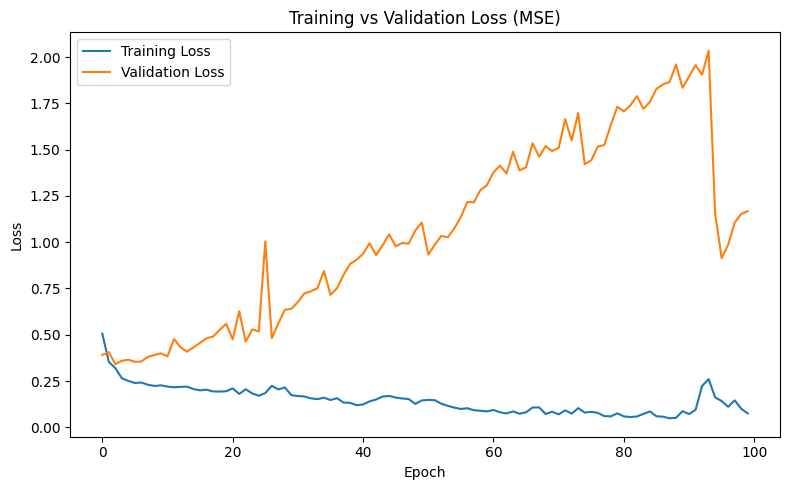

In [41]:
from sklearn.metrics import mean_squared_error

# get predictions
y_train_pred = (model.predict(X_train_scaled) > 0.5).astype(int)

# calculate MSE
mse_train = mean_squared_error(y_train, y_train_pred)

print(f"MSE for Training Set: {mse_train:.4f}")

#Trainign vs Validation Loss

# get loss from training history (loss = binary crossentropy, not MSE)
# so we recalculate MSE per epoch manually using history

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

#### **Explanation:**

**MSE = Mean Squared Error**
Measures how far the model predictions are from the actual values

- Since my  training accuracy was 95.56%, expect MSE to be very low (~0.04)
- This means on average the model makes very few wrong predictions on training data

## **H. Discuss whether the network overfits or underfits for different hidden neuron settings.**

## **I. Show confusion matrix and compute F1-score.**

### **1. Confusion Matrix**

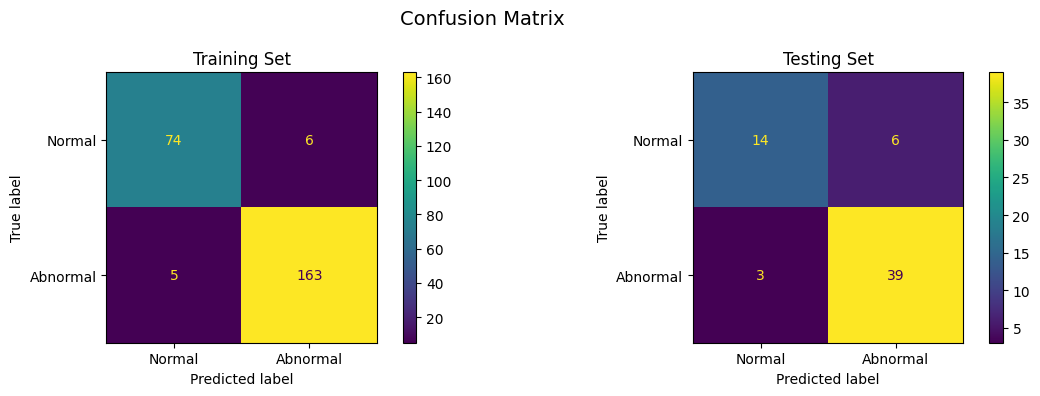

In [37]:
#===Confusion Matrix====

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training confusion matrix
cm_train = confusion_matrix(y_train, y_train_pred)
ConfusionMatrixDisplay(cm_train, display_labels=['Normal','Abnormal']).plot(ax=axes[0])
axes[0].set_title('Training Set')

# Testing confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm_test, display_labels=['Normal','Abnormal']).plot(ax=axes[1])
axes[1].set_title('Testing Set')

plt.suptitle('Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

#### **Explanation:**

**Training Set Performance**

- Only 6 Normal patients were wrongly predicted as Abnormal and only 5 Abnormal patients were missed


**Testing Set Performance**

- The confusion matrix shows 6 Normal patients wrongly classified as Abnormal and 3 Abnormal patients missed

###  **2. F-1 score**

In [42]:
from sklearn.metrics import f1_score

# F1 score for training set
f1_train = f1_score(y_train, y_train_pred)

# F1 score for testing set
f1_test = f1_score(y_test, y_test_pred)

print(f"F1 Score - Training Set : {f1_train:.4f}")
print(f"F1 Score - Testing Set  : {f1_test:.4f}")

#F-1 Score for each class

f1_train_each = f1_score(y_train, y_train_pred, average=None)
f1_test_each  = f1_score(y_test,  y_test_pred,  average=None)

print("Training F1 per class:")
print(f"  Normal   : {f1_train_each[0]:.4f}")
print(f"  Abnormal : {f1_train_each[1]:.4f}")

print("\nTesting F1 per class:")
print(f"  Normal   : {f1_test_each[0]:.4f}")
print(f"  Abnormal : {f1_test_each[1]:.4f}")

F1 Score - Training Set : 0.9674
F1 Score - Testing Set  : 0.8966
Training F1 per class:
  Normal   : 0.9308
  Abnormal : 0.9674

Testing F1 per class:
  Normal   : 0.7568
  Abnormal : 0.8966


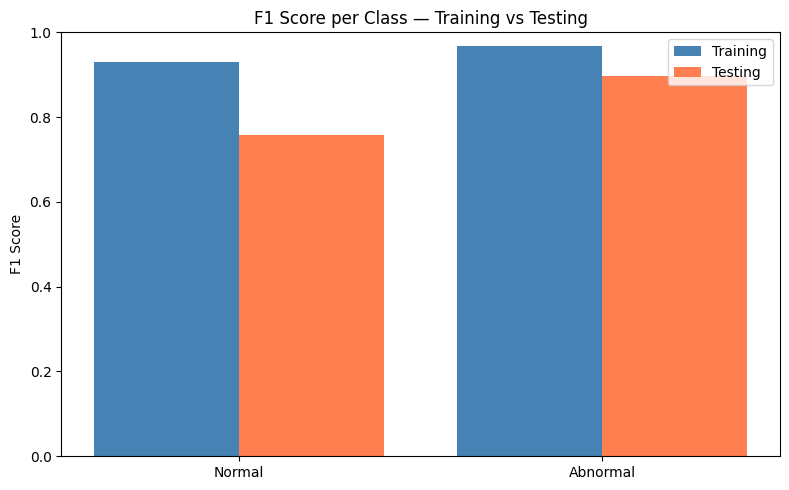

In [43]:
classes    = ['Normal', 'Abnormal']
f1_train_vals = f1_train_each
f1_test_vals  = f1_test_each

x = range(len(classes))

plt.figure(figsize=(8, 5))
plt.bar([i - 0.2 for i in x], f1_train_vals, width=0.4, label='Training',  color='steelblue')
plt.bar([i + 0.2 for i in x], f1_test_vals,  width=0.4, label='Testing',   color='coral')
plt.xticks(x, classes)
plt.ylabel('F1 Score')
plt.title('F1 Score per Class — Training vs Testing')
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

#### **Explanation:**

**What is F-1 score?**
A model could predict everything as Abnormal and still get 70% accuracy
F1 Score catches this problem by considering both Precision and Recall

- Abnormal F1 is higher in both sets — model is better at detecting Abnormal
- Normal F1 drops from training to testing — model struggles more with Normal on unseen data
- Overall F1 is strong showing the model performs well ✅

## **J. Plot the learning process**

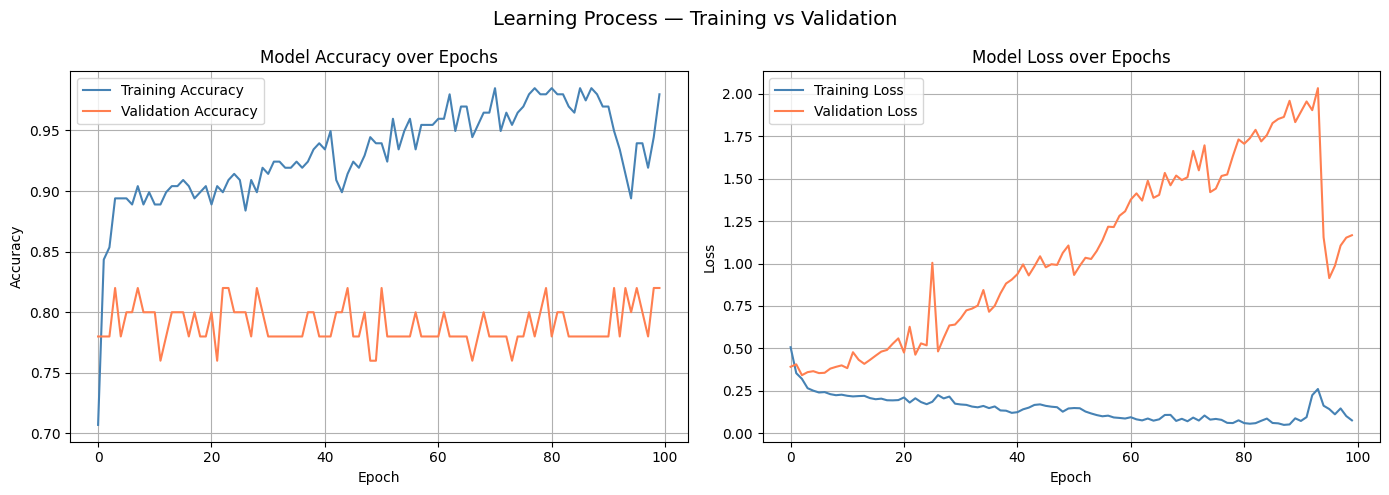

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy Plot ---
axes[0].plot(history.history['accuracy'],     label='Training Accuracy',   color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='coral')
axes[0].set_title('Model Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# --- Loss Plot ---
axes[1].plot(history.history['loss'],     label='Training Loss',   color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='coral')
axes[1].set_title('Model Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Learning Process — Training vs Validation', fontsize=14)
plt.tight_layout()
plt.show()

#### **Explanation:**


**Accuracy Plot (Left)**

- Training accuracy (blue) — starts at 71% and rises to ~97%
- Validation accuracy (orange) — starts at ~80% and stays flat around 80% the whole time
- The big gap between blue and orange lines = clear overfitting
- Validation accuracy never improves after epoch 10 — model stopped generalizing


**Loss Plot (Right)**

- Training loss (blue) — starts at 0.5 and keeps dropping to near 0
- Validation loss (orange) — starts okay but keeps rising from epoch 20 onwards
- This is a classic overfitting sign — training loss goes down while validation loss goes up
- They move in opposite directions which is bad


Overall, Model is memorizing the training data. It performs great on training but fails to generalize to new data. The learning process is stable and converging which confirms the model is learning correctly.